# Машинное обучение, ФКН ВШЭ

## Практическое домашнее задание 3.2  Продвинутая генерация признаков

### Общая информация

Дата выдачи: 23.02.2026

Мягкий дедлайн: 12.03.2026 23:59MSK

Жесткий дедлайн: 16.03.2026 23:59MSK

### О задании

В данном задании вы познакомитесь с менее тривиальными подходами для создания новых признаков в табличном машинном обучении. Вам понадобится подумать над тем, зачем мы делаем те или иные преобразования, научиться принимать решения, дающие наилучшие результаты, и узнать, как реализовывать их при помощи библиотек

### Оценивание и штрафы

См. базовую часть

### Формат сдачи
Задания сдаются через систему Anytask. Инвайт можно найти на странице курса. Присылать необходимо ноутбук с выполненным заданием. Сам ноутбук называйте в формате **homework-practice-03-advanced-Username.ipynb**, где Username — ваша фамилия.

### **Введение**

В этой части ноутбука задания посложнее дефолтного фит трансформа. Максимальная оценка за оба — 8 баллов, остальное вы можете получить, если примете участие в соревновании, и всего можете выбить аж 13 из 10. Тут ожидается больше самостоятельности, как от (почти) полноценной рабочей единицы: 
- Вы **сами** решаете, что <font color="#d18753">**хотите**</font> делать. Пункты можно делать частично, можно скипать или сделать часть, **максимум баллов ограничен двумя**. **Посмотрите на все из них**, прежде чем приступать
- Вы **сами** чистите данные, если чуете в них подвох (теперь они далеко не такие няшные)
- Вы **сами** <font color="#f68c9d">**обосновываете**</font> (в голове, если не указано явно), могут они вам вообще помочь или нет (часть пунктов явно сильнее других)

Все прочие пожелания по тому, как строить графики, на чём фиттить, а на чём предиктить, сохраняются, будьте внимательны. Во всех пунктах с 📈 нужно добиться хотя бы минимального улучшения, относительно бейзлайна (того, что вышло в части **base**) чтобы получить балл (даже если улучшение на 0.005)

Ещё раз обратите внимание, что **максимум за advanced часть — 2 балла**, делать всё не нужно, только самое приятное. Мы в вас верим!

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import nltk
import pymorphy3 as morph

### **Часть 4. Текста** (1.5 балла) <img align="center" src="https://static.wikia.nocookie.net/dota2_gamepedia/images/4/4f/Emoticon_blush.gif/revision/latest?cb=20180504011409">

В которой студент знакомится с внутренним миром дотеров

#### **Задание 4.1. Предобработка текста** (0.75 балла)

<span style="color:grey"><font size="1">Если вам когда-либо приходила в голову мысль, что создание Интернета было ошибкой, то, что ж, после этого задания сомнения могут отпасть.</font></span>

Для некоторых матчей имеется информация о том, что писали местные аборигены, в течение тех же **15 минут от начала матча**. К сожалению, доселе мы работали лишь с таблицами, а не с текстами, но не беда, простейшие подходы нейросетей не требуют, а в простых задачах, вроде бинарной классификации, работать будут не хуже

Откройте датафрейм `game_chat.csv`, выведите парочку текстов, посмотрите, как они устроены, как там хранятся множественные сообщения,  и так далее, что у нас есть, а чего, увы, нет

In [2]:
df_chat = pd.read_csv("data/game_chat.csv")
df_chat.loc[0, "dire_chat"]

'саппортам | U LAGGING BRAH | stack..... | шлюх'

In [3]:
df_train = pd.read_csv("data/df_train_proc.csv")
df_test = pd.read_csv("data/df_test_proc.csv")

Дём дальше. Тексты нужно готовить, прежде чем пихать их в модель. Оценивать выбросы здесь довольно проблематично, в силу специфики дотерских сообщений, хотя вы, конечно, можете попытаться. Речь здесь про базовую предобработку.

Задача минимум, тут мы вам поможем:
- Разобраться с библиотекой `nltk` и разбить текст на токены — отдельные сущности, составляющие текст (чаще всего слова, но бывает и что-то другое, надо разобраться). Как бить текст - вопрос творческий, в целом подойдёт любой способ, но какие-то [токенизаторы](https://www.nltk.org/api/nltk.tokenize.html) могут сразу покрыть часть проблем с текстами в задаче максимум
- Лемматизировать текст (привести слова к начальной форме). <font color="#d18753">**Варианта два**</font>: манкипатчить [`pymorphy2`](https://pymorphy2.readthedocs.io/en/stable/) или откатывать версии (там вылезет ошибка, если у вас слишком новый питон), либо применять [`mystem`](https://pypi.org/project/pymystem3/), что может затянуться на несколько часов, зато лемматизация будет точнее

Задача максимум, тут вам нужно понять, как всё обработать, самим (включать, не включать, выкинуть, оставить — валидны **все** варианты, но только, если, есть, <font color="#f68c9d">**обоснование**</font>):
- повторы символов
- знаки препинания
- стоп-слова
- нижний регистр
  
Вам нужно пройтись по всем пунктам, не обязательно в этом порядке. Если найдёте что-то ещё — круто, молодцы, можно тоже пофиксить

<div style="border-left: 5px solid #ff748c; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** ну что, как обрабатываем текст?

**Ответ:** Ну сначала приведем все к нижнему регистру, потому что бы для модели эмбеддингов все наши слова были в одном формате. Также, чтобы наша лемматизация проходила хорошо, оставим только максимум два потовряющихся символа.

Далее токенизируем, уберем знаки препинания, потому что дотеры не умеют их ставить, также уберем стоп слова, потому что они просто будут вносить шум в наши последующие эмбеддинги и будут плохо влиять на модель.

</div>

In [4]:
from nltk.tokenize import WordPunctTokenizer
from nltk.corpus import stopwords
import re
nltk.download("stopwords", quiet=True)

tokenizer = WordPunctTokenizer()
m = morph.MorphAnalyzer()
stop = set(stopwords.words("russian")) | set(stopwords.words("english"))

def preprocessing(text: str):
    text = text.lower()
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)
    
    tok = tokenizer.tokenize(text)
    tok = [t for t in tok if re.match(r"^[а-яёa-z]+$", t)]
    filt_tok = [t for t in tok if t not in stop]
    filt_tok = [m.parse(t)[0].normal_form for t in filt_tok]
    
    return " ".join(filt_tok)
    

# можете проверить, что делает ваша функция, на тесте ниже

print(preprocessing("Ляяя, ваша мама такая красивая, ну вылитый пудж)))0"))

ляя ваш мама такой красивый вылитый пуджа


In [5]:
df_chat["rad_proc"] = df_chat["radiant_chat"].fillna("").apply(preprocessing)
df_chat["dire_proc"] = df_chat["dire_chat"].fillna("").apply(preprocessing)
df_chat

,match_id,radiant_chat,dire_chat,rad_proc,dire_proc
0,235435,потренируйся с ботами????,саппортам | U LAGGING BRAH | stack..... | шлюх,потренироваться бот,саппорт u lagging brah stack шлюха
1,102127,NaN,NaN,,
2,383046,u just buy levels blue? | fa ge,NaN,u buy levels blue fa ge,
3,729879,NaN,NaN,,
4,126886,NaN,NaN,,
...,...,...,...,...,...
700833,125302,NaN,NaN,,
700834,673218,NaN,NaN,,
700835,610308,NaN,NaN,,
700836,287174,NaN,NaN,,


#### 📈 **Задание 4.2. Векторизация** (0.5 балла)

Ура, если у вас получились токены, то наконец-то можно что-то закодировать, но как? Рад, что вы спросили. Читайте конспект семинаров или документацию

<table width="800" border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th width="50%">
      <font color="#d18753">CountVectorizer</font>
    </th>
    <th width="50%">
      <font color="#d18753">TfIdfVectorizer</font>
    </th>
  </tr>
  <tr>
    <td valign="top">
      Берёт и считает, сколько раз в тексте <br>
      встретилось то или иное слово. Похож <br>
      на наш энкодер из части 2.
      <br><br>
      <table border="1" cellpadding="4" cellspacing="0">
        <thead>
          <tr>
            <th scope="col">word_1</th>
            <th scope="col">word_2</th>
            <th scope="col">word_3</th>
            <th scope="col">...</th>
            <th scope="col">word_m</th>
          </tr>
        </thead>
        <tbody>
          <tr>
            <td>1</td>
            <td>0</td>
            <td>2</td>
            <td>...</td>
            <td>100</td>
          </tr>
        </tbody>
      </table>
    </td>
    <td valign="top">
      Более хитрая штука: вместе с количеством слов (tf)<br>
      считает их важность (idf). Слова, встречающиеся <br>
      во всех документах, считаются не важными<br>
      и зануляются (idf = log1).
      <br><br>
      <table border="1" cellpadding="4" cellspacing="0">
        <thead>
          <tr>
            <th scope="col"></th>
            <th scope="col">word_1</th>
            <th scope="col">word_2</th>
            <th scope="col">word_3</th>
            <th scope="col">...</th>
            <th scope="col">word_m</th>
          </tr>
        </thead>
        <tbody>
          <tr>
            <td><b>text_1</b></td>
            <td>1*log2</td>
            <td>0</td>
            <td>2*log2</td>
            <td>...</td>
            <td>100*log1</td>
          </tr>
          <tr>
            <td><b>text_2</b></td>
            <td>0</td>
            <td>10*log2</td>
            <td>0</td>
            <td>...</td>
            <td>100*log1</td>
          </tr>
        </tbody>
      </table>
    </td>
  </tr>
</table>


Оба векторайзера хороши, но у каждого из них есть <font color="#d18753">**гиперпараметры**</font>. Естественно, они повлияют на качество, <font color="#d18753">**можете подобрать их**</font> попозже, дефолтные тоже должны показать эффект

Обучите по векторайзеру на чатах Radiant и Dire. Приклейте результат к вашему датасету и обучите модель на всём получившемся великолепии (sparse формат убирать не рекомендуется)

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_rad = TfidfVectorizer(max_features=50)
tfidf_dire = TfidfVectorizer(max_features=50)

In [7]:
df_train = df_train.merge(df_chat[["match_id", "rad_proc", "dire_proc"]], on="match_id", how="left")
df_test  = df_test.merge(df_chat[["match_id", "rad_proc", "dire_proc"]], on="match_id", how="left")

df_train[["rad_proc", "dire_proc"]] = df_train[["rad_proc", "dire_proc"]].fillna("")
df_test[["rad_proc", "dire_proc"]]  = df_test[["rad_proc", "dire_proc"]].fillna("")


tfidf_rad.fit(df_train["rad_proc"])
tfidf_dire.fit(df_train["dire_proc"])

X_rad_train = tfidf_rad.transform(df_train["rad_proc"])
X_dire_train = tfidf_dire.transform(df_train["dire_proc"])

X_rad_test = tfidf_rad.transform(df_test["rad_proc"])
X_dire_test = tfidf_dire.transform(df_test["dire_proc"])

In [8]:
text_cols = ["rad_proc", "dire_proc"]
minus_train = ["radiant_win", "match_id", "date", "duration", "avg_mmr"] + text_cols

features_train = [col for col in df_train.columns if col not in minus_train]
features_test  = [col for col in features_train if col in df_test.columns]

In [9]:
from scipy.sparse import hstack, csr_matrix
from sklearn.linear_model import LogisticRegression


X_train = hstack([csr_matrix(df_train[features_train].values.astype(float)), X_rad_train, X_dire_train])
X_test = hstack([csr_matrix(df_test[features_test].values.astype(float)), X_rad_test, X_dire_test])
y_train = df_train["radiant_win"]

model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)
y_pred = model.predict_proba(X_test)[:, 1]

In [10]:
prediction = pd.DataFrame(columns=["ID", "Value"])
prediction["ID"] = df_test["match_id"]
prediction["Value"] = y_pred
prediction.to_csv("data/adv_pred.csv", index=False, encoding="utf8")

Джини не то, что не поднялось, оно упало...

#### **Задание 4.3. Визуализация** (0.25 балла)

Для любителей графиков есть малюсенькое задание: визуализируйте облако слов с наибольшими по модулю весами (разделите их на условно *"позитивные"* и *"негативные"*)

In [11]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

<div style="border-left: 5px solid #ff748c; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** что думаете? Сейчас и вообще по модели — негативные получились слова или так, едва?

**Ответ:** Ну как-то видимо засчет того, что их очень мало, прибавки к джини они вообще не дали... Поэтому попросту не будем их брать в нашу модель, получается сизифов труд организовали, не хватает подписи, что ВОЗМОЖНО НИЧЕГО НЕ ЗАРАБОТАЕТ и вы будете себя в этом винить.

</div>

### **Часть 5. Агрегации** (1.75 балла) <img align="center" src="https://static.wikia.nocookie.net/dota2_gamepedia/images/4/4a/Techies_emoticon.gif/revision/latest?cb=20180504014918">

В которой студент начинает ведать

#### 📈 **Задание 5.1. Статистики матча** (0.75 балла)

Есть у нас в данных большой кусок про advantage — преимущество команды сил Света с точностью до минуты, по золоту и опыту, всё так же **в пределах 15 минут**. Лежат они в `dota_adv.csv`. Чем больше число, тем больше шанс на победу — всё просто. Только график, как правило, не линеен.

С ними в очередной раз есть проблемы — необходимо разобраться, как они там лежат, и всё ли там в порядке со значениями, но это меньшая из проблем. А также нарисовать парочку advantage, чтобы было понимание, как они себя ведут

In [12]:
df_adv = pd.read_csv("data/dota_adv.csv")
df_adv.loc[0, "radiant_exp_adv"]

'[   0   68  658 1397 1435 2118 2118 1923 1923 1923 2494 3772 3734 4661\n 4661 3311]'

Криво они там конечно лежат, просто строчкой, поэтому их надо достать и сделать простой народный массив.

In [13]:
df_adv["radiant_exp_adv"] = df_adv["radiant_exp_adv"].apply(lambda x: np.fromstring(x.strip("[]"), sep='\n').astype(int))
df_adv["radiant_gold_adv"] = df_adv["radiant_gold_adv"].apply(lambda x: np.fromstring(x.strip("[]"), sep='\n').astype(int))

In [14]:
len(df_adv.loc[0, "radiant_exp_adv"])

16

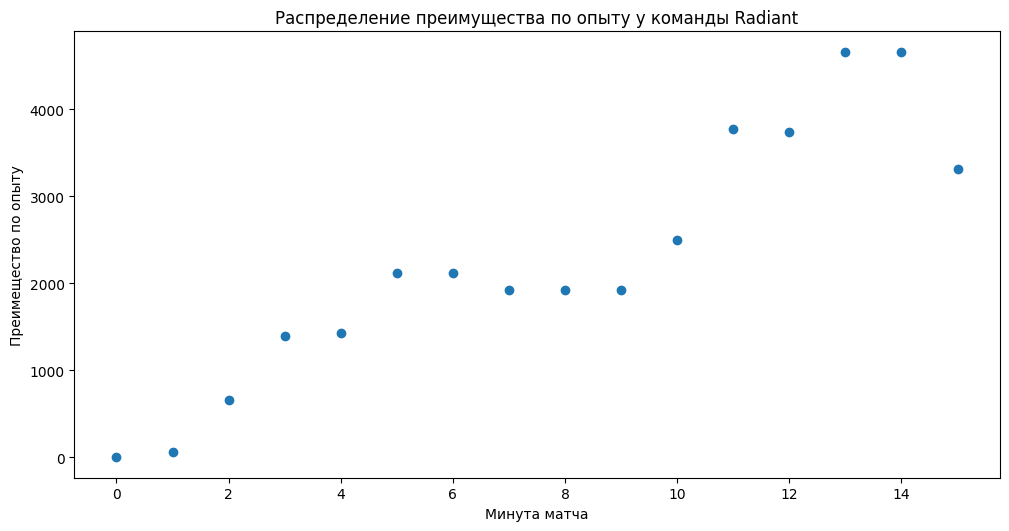

In [15]:
plt.figure(figsize=(10, 5))
plt.scatter([i for i in range(0, 16)], df_adv.loc[0, "radiant_exp_adv"])
plt.tight_layout()
plt.title("Распределение преимущества по опыту у команды Radiant")
plt.xlabel("Минута матча")
plt.ylabel("Преимещество по опыту")
plt.show();

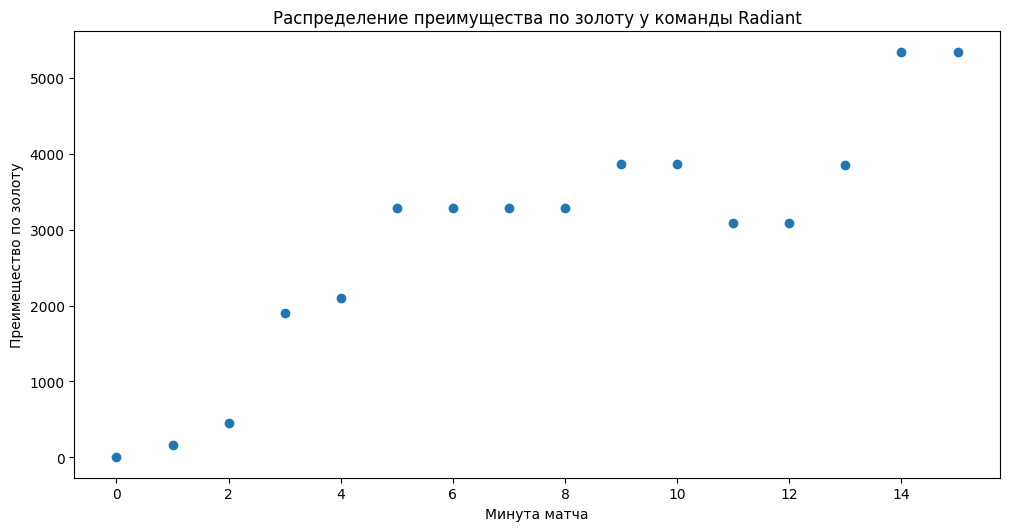

In [16]:
plt.figure(figsize=(10, 5))
plt.scatter([i for i in range(0, 16)], df_adv.loc[0, "radiant_gold_adv"])
plt.tight_layout()
plt.title("Распределение преимущества по золоту у команды Radiant")
plt.xlabel("Минута матча")
plt.ylabel("Преимещество по золоту")
plt.show();

Вот это конечно у нас тут выбросики блинб, давайте их почистим... Я тут еще интересный факт увидел, врядли у нас с 0 минуты может быть преимещество хоть по чему-то не 0, давайте тогда заменим выбросные значения в массивах на средние из обычных данных.

In [17]:
df_adv[df_adv["radiant_gold_adv"].apply(lambda x: len(x) > 0 and np.max(x) > 40000)].head(3)

,match_id,radiant_gold_adv,radiant_exp_adv
36377,567318,"[1241251, 1242499, 1244174, 1245743, 1246236, ...","[32400, 32400, 32400, 32400, 32400, 32400, 270..."
59658,556768,"[100963, 100254, 103063, 104768, 105648, 10568...","[32400, 31877, 31467, 30981, 30537, 29611, 289..."
135173,565145,"[2141709, 2142009, 2143653, 2143753, 2145044, ...","[32400, 32400, 32400, 32400, 32400, 32400, 224..."


In [18]:
# gold = 100_000
# exp  = 70_000

# gold_mean_arr = np.mean([x for x in df_adv["radiant_gold_adv"] if len(x) == 16 and np.abs(x).max() < gold], axis=0)
# exp_mean_arr = np.mean([x for x in df_adv["radiant_exp_adv"] if len(x) == 16 and np.abs(x).max() < exp], axis=0) 

# df_adv["radiant_gold_adv"] = df_adv["radiant_gold_adv"].apply(lambda x: gold_mean_arr if len(x) == 0 or np.abs(x).max() >= gold else x)
# df_adv["radiant_exp_adv"] = df_adv["radiant_exp_adv"].apply(lambda x: exp_mean_arr if len(x) == 0 or np.abs(x).max() >= exp else x)


Бесполезно с ними бороться, значит какие-то из них у нас попадаются в тесте и качество падает...

Для начала возьмём простые агрегации. Можете взять те, что вам знакомы (статистики - среднее, стд и др.), можете взять фан факты в вашей любимой библиотеке для данных, например [тут](https://docs.pola.rs/api/python/stable/reference/expressions/computation.html) или [тут](https://docs.pola.rs/api/python/stable/reference/expressions/aggregation.html).

Задание:
- взять 4 статистики из библиотеки, применить к обеим колонкам `_adv`, <font color="#f68c9d">**обдумать**</font>, почему именно они
- одну из статистику выше разбить по командам, и точно так же примените к колонкам (получится что-то типа `agg_xp` -> `agg_dire_xp`, `agg_radiant_xp`)

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Тут мы встаём на скользкую дорожку переобучения. Агрегаций можно сделать **очень** много. Добавьте их все, и ваша модель превратится в тыкву. Удобнее будет сразу бить их на группы, например `features_last`, `features_q25`, `features_kurtosis_dire_10min+` и так далее, в зависимости от степени упоротости

C другой стороны, агрегации это самая сильная группа фичей, и для десяточки лучше целиться именно в них

</div>

<div style="border-left: 5px solid #f68c9d; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** какие агрегации берём?

**Ответ:** Ну как будто точно нужно взять среднее и стандартное отколнение - чтобы понять, насколько игра идет стабильно или есть какое-то доминирование(МОПовцы такое любят).

 Еще по хорошему надо взять пиковое преимущество и последнее значение для предсказания, чтобы выявить ближаюшую команду к победе после 15 минут. Вообще хочется конечно упороться и взять какое-то взвешенное среднее экспы и голды, потому что они как бы линейно зависимы между собой.

 По командам разобьем аггрегацию по максимуму, так как мы не берем минимальное премищество.

</div>

In [19]:
df_adv["exp_adv_mean"] = df_adv["radiant_exp_adv"].apply(np.mean)
df_adv["gold_adv_mean"] = df_adv["radiant_gold_adv"].apply(np.mean)

df_adv["exp_adv_std"] = df_adv["radiant_exp_adv"].apply(np.std)
df_adv["gold_adv_std"] = df_adv["radiant_gold_adv"].apply(np.std)

df_adv["exp_adv_max"] = df_adv["radiant_exp_adv"].apply(lambda x: np.max(x) if len(x) > 0 else np.nan)
# df_adv["gold_adv_max"] = df_adv["radiant_gold_adv"].apply(lambda x: np.max(x) if len(x) > 0 else np.nan)

df_adv["exp_adv_last"] = df_adv["radiant_exp_adv"].apply(lambda x: x[-1] if len(x) > 0 else np.nan)
df_adv["gold_adv_last"] = df_adv["radiant_gold_adv"].apply(lambda x: x[-1] if len(x) > 0 else np.nan)

df_adv["gold_adv_max_radiant"] = df_adv["radiant_gold_adv"].apply(lambda x: np.max(x) if len(x) > 0 else np.nan)
df_adv["gold_adv_max_dire"] = df_adv["radiant_gold_adv"].apply(lambda x: -np.min(x) if len(x) > 0 else np.nan)

df_adv

/Users/ilanizankovskij/Documents/vs_code/ml_hse/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/ilanizankovskij/Documents/vs_code/ml_hse/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/ilanizankovskij/Documents/vs_code/ml_hse/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/ilanizankovskij/Documents/vs_code/ml_hse/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Users/ilanizankovskij/Documents/vs_code/ml_hse/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encount

,match_id,radiant_gold_adv,radiant_exp_adv,exp_adv_mean,gold_adv_mean,exp_adv_std,gold_adv_std,exp_adv_max,exp_adv_last,gold_adv_last,gold_adv_max_radiant,gold_adv_max_dire
0,526846,"[0, 159, 452, 1904, 2100, 3290, 3290, 3290, 32...","[0, 68, 658, 1397, 1435, 2118, 2118, 1923, 192...",2262.2500,2887.5000,1401.628406,1559.052797,4661.0,3311.0,5342.0,5342.0,0.0
1,511496,"[0, -151, -141, 12, -165, -151, -151, 4, 377, ...","[0, 1, -136, 243, -270, -8, -8, -169, -169, 18...",191.6250,933.8750,385.377717,1342.763702,931.0,201.0,3698.0,3698.0,165.0
2,90272,[],[],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,153647,[],[],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,694826,[],[],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
767817,602640,"[0, 66, -5, -4, 286, 457, 457, 251, 564, 135, ...","[0, -207, -558, -807, -686, -917, -917, -917, ...",773.0625,-66.0625,2481.089818,540.721332,7743.0,7743.0,-143.0,564.0,1589.0
767818,757925,"[0, 32, -95, -58, -424, -1108, -1108, -1108, -...","[0, 76, 217, 133, -116, -412, -412, -412, -713...",-69.0625,-104.9375,306.588378,814.614746,225.0,225.0,823.0,1229.0,1108.0
767819,700080,[],[],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
767820,289295,[],[],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Обучите модель по агрегациям (одной группе или нескольким) + предыдущим фичам. Чтобы получить фулл балл, придётся показать, что хотя бы минимальный импрув есть, относительно бейзлайна

In [20]:
df_train = df_train.drop(columns=["rad_proc", "dire_proc"])
df_test = df_test.drop(columns=["rad_proc", "dire_proc"])

df_train = df_train.merge(df_adv.drop(columns=["radiant_gold_adv", "radiant_exp_adv"]), on="match_id", how="left")
df_test = df_test.merge(df_adv.drop(columns=["radiant_gold_adv", "radiant_exp_adv"]), on="match_id", how="left")

In [21]:
agg_cols = ["exp_adv_mean", "gold_adv_mean", "exp_adv_std", "gold_adv_std", "exp_adv_max", "exp_adv_last", "gold_adv_last", "gold_adv_max_radiant", "gold_adv_max_dire"]

df_train[agg_cols] = df_train[agg_cols].fillna(0)
df_test[agg_cols] = df_test[agg_cols].fillna(0)
df_train.isna().sum()

match_id                0
date                    0
duration                0
radiant_win             0
avg_mmr                 0
                       ..
exp_adv_max             0
exp_adv_last            0
gold_adv_last           0
gold_adv_max_radiant    0
gold_adv_max_dire       0
Length: 152, dtype: int64

Я чуток из будущего, давайте попроубуем добавить еще аггрегаций, чтобы вообще по красоте было 

Давайте также отскалируем наши аггрегационные признаки, чтобы улучшить качество. Так как у нас в данных какое-то невероятное количество пропусков, заполним их 0 и обучим скейлер только на ненулевых строчках.

In [22]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
mask = df_train["exp_adv_mean"] != 0
scaler.fit(df_train.loc[mask, agg_cols])

df_train[agg_cols] = scaler.transform(df_train[agg_cols])
df_test[agg_cols] = scaler.transform(df_test[agg_cols])

In [23]:
df_train

,match_id,date,duration,radiant_win,avg_mmr,region_Europe West,region_South Africa,region_SE Asia,region_Middle East,region_US East,...,game_mode_8,exp_adv_mean,gold_adv_mean,exp_adv_std,gold_adv_std,exp_adv_max,exp_adv_last,gold_adv_last,gold_adv_max_radiant,gold_adv_max_dire
0,1,2024-02-12,2625,False,3519.70,1,0,0,0,0,...,0,-0.154123,0.002364,-1.770613,-0.004173,-0.998619,-0.241414,-0.231424,-0.003073,-0.00349
1,2,2024-04-08,7526,True,2330.90,0,1,0,0,0,...,0,-0.154123,0.002364,-1.770613,-0.004173,-0.998619,-0.241414,-0.231424,-0.003073,-0.00349
2,3,2024-06-16,2831,True,1579.60,0,0,1,0,0,...,0,-0.154123,0.002364,-1.770613,-0.004173,-0.998619,-0.241414,-0.231424,-0.003073,-0.00349
3,4,2024-09-16,1438,False,2846.85,0,0,0,1,0,...,0,-0.154123,0.002364,-1.770613,-0.004173,-0.998619,-0.241414,-0.231424,-0.003073,-0.00349
4,5,2024-03-31,2051,True,2846.85,0,1,0,0,0,...,0,-0.154123,0.002364,-1.770613,-0.004173,-0.998619,-0.241414,-0.231424,-0.003073,-0.00349
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
641085,767815,2024-07-13,1888,False,401.10,0,0,0,0,1,...,0,-0.154123,0.002364,-1.770613,-0.004173,-0.998619,-0.241414,-0.231424,-0.003073,-0.00349
641086,767817,2024-02-02,2789,False,2846.85,0,0,0,0,0,...,0,-0.154123,0.002364,-1.770613,-0.004173,-0.998619,-0.241414,-0.231424,-0.003073,-0.00349
641087,767818,2024-07-03,1197,False,1953.40,0,0,0,0,0,...,0,-0.154123,0.002364,-1.770613,-0.004173,-0.998619,-0.241414,-0.231424,-0.003073,-0.00349
641088,767820,2024-11-08,4155,True,2846.85,0,0,0,1,0,...,0,-0.154123,0.002364,-1.770613,-0.004173,-0.998619,-0.241414,-0.231424,-0.003073,-0.00349


In [24]:
features_train = [col for col in df_train.columns if col not in minus_train]
features_test = [col for col in features_train if col in df_test.columns]

model = LogisticRegression(max_iter=20000)
model.fit(df_train[features_train], df_train["radiant_win"])
y_pred = model.predict_proba(df_test[features_test])[:, 1]
y_pred

array([0.40347756, 0.60446484, 0.60476568, ..., 0.16987472, 0.70422127,
       0.87132528], shape=(59748,))

In [25]:
coefs = pd.Series(model.coef_[0], index=features_train)
coefs.abs().sort_values(ascending=True).head(20)

hero_47              0.001702
hero_59              0.003996
gold_adv_mean        0.004588
hero_64              0.005128
game_mode_8          0.005401
hero_14              0.006061
days_last_patch      0.006449
hero_38              0.007555
hero_78              0.011557
hero_41              0.011577
gold_adv_std         0.011887
gold_adv_max_dire    0.013055
hero_100             0.014182
hero_44              0.017315
hero_26              0.018723
hero_29              0.018852
game_mode_11         0.019013
hero_45              0.019920
hero_107             0.023850
hero_60              0.024099
dtype: float64

Некоторые из наших аггрегаций абсолютно не несут веса для модели, поэтому их можно спокойно так обрезать и придумать новые, качественные.

In [26]:
agg_cols_all = ["exp_adv_mean", "gold_adv_mean", "exp_adv_std", "gold_adv_std", 
                "exp_adv_max", "exp_adv_last", "gold_adv_last", 
                "gold_adv_max_radiant", "gold_adv_max_dire"]

coefs[agg_cols_all].abs().sort_values(ascending=False)

gold_adv_last           0.811261
exp_adv_last            0.424134
exp_adv_mean            0.333246
exp_adv_max             0.265756
gold_adv_max_radiant    0.067628
exp_adv_std             0.025475
gold_adv_max_dire       0.013055
gold_adv_std            0.011887
gold_adv_mean           0.004588
dtype: float64

Видно по весам нашей модели, что признаки gold_adv_std и gold_adv_max_dire не несут почти никакой пользы в итоговый результат, давайте их заменим на новые аггрегации.

In [27]:
df_train = df_train.drop(columns=["gold_adv_std", "gold_adv_max_dire"])
df_test = df_test.drop(columns=["gold_adv_std", "gold_adv_max_dire"])

Добавим признаки за 5, 10 минут по преимуществу, а также извратимся, какое ускорение роста происходит, то есть последнее значение минус за 5, и за 10 минут, что будет примерно как тренд, также добавим бинарный признак, кто лидирует по итогам 15 минут.

In [28]:
df_adv["gold_adv_min5"] = df_adv["radiant_gold_adv"].apply(lambda x: x[5] if len(x) > 0 else 0)
df_adv["exp_adv_min5"] = df_adv["radiant_exp_adv"].apply(lambda x: x[5] if len(x) > 0 else 0)

df_adv["gold_adv_min10"] = df_adv["radiant_gold_adv"].apply(lambda x: x[10] if len(x) > 0 else 0)
df_adv["exp_adv_min10"] = df_adv["radiant_exp_adv"].apply(lambda x: x[10] if len(x) > 0 else 0)

df_adv["gold_adv_acc"] = df_adv["gold_adv_last"] - df_adv["gold_adv_min5"]
df_adv["exp_adv_acc"] = df_adv["exp_adv_last"] - df_adv["exp_adv_min5"]

df_adv["gold_win_end"] = (df_adv["gold_adv_last"] > 0).astype(int)
df_adv["exp_win_end"] = (df_adv["exp_adv_last"] > 0).astype(int)
df_adv

,match_id,radiant_gold_adv,radiant_exp_adv,exp_adv_mean,gold_adv_mean,exp_adv_std,gold_adv_std,exp_adv_max,exp_adv_last,gold_adv_last,gold_adv_max_radiant,gold_adv_max_dire,gold_adv_min5,exp_adv_min5,gold_adv_min10,exp_adv_min10,gold_adv_acc,exp_adv_acc,gold_win_end,exp_win_end
0,526846,"[0, 159, 452, 1904, 2100, 3290, 3290, 3290, 32...","[0, 68, 658, 1397, 1435, 2118, 2118, 1923, 192...",2262.2500,2887.5000,1401.628406,1559.052797,4661.0,3311.0,5342.0,5342.0,0.0,3290,2118,3859,2494,2052.0,1193.0,1,1
1,511496,"[0, -151, -141, 12, -165, -151, -151, 4, 377, ...","[0, 1, -136, 243, -270, -8, -8, -169, -169, 18...",191.6250,933.8750,385.377717,1342.763702,931.0,201.0,3698.0,3698.0,165.0,-151,-8,1222,931,3849.0,209.0,1,1
2,90272,[],[],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,NaN,NaN,0,0
3,153647,[],[],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,NaN,NaN,0,0
4,694826,[],[],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,NaN,NaN,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
767817,602640,"[0, 66, -5, -4, 286, 457, 457, 251, 564, 135, ...","[0, -207, -558, -807, -686, -917, -917, -917, ...",773.0625,-66.0625,2481.089818,540.721332,7743.0,7743.0,-143.0,564.0,1589.0,457,-917,-132,-76,-600.0,8660.0,0,1
767818,757925,"[0, 32, -95, -58, -424, -1108, -1108, -1108, -...","[0, 76, 217, 133, -116, -412, -412, -412, -713...",-69.0625,-104.9375,306.588378,814.614746,225.0,225.0,823.0,1229.0,1108.0,-1108,-412,-754,-136,1931.0,637.0,1,1
767819,700080,[],[],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,NaN,NaN,0,0
767820,289295,[],[],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,NaN,NaN,0,0


In [29]:
cols = ["gold_adv_min5", "exp_adv_min5", "gold_adv_min10", "exp_adv_min10", "gold_adv_acc", "exp_adv_acc", "gold_win_end", "exp_win_end"]

df_adv_new = df_adv[["match_id"] + cols].drop_duplicates("match_id")
df_train = df_train.merge(df_adv_new, on="match_id", how="left")
df_test  = df_test.merge(df_adv_new, on="match_id", how="left")

mask_train = df_train[cols[0]].notna()
mask_test  = df_test[cols[0]].notna()

df_train[cols] = df_train[cols].astype(float)
df_test[cols] = df_test[cols].astype(float)

scaler = StandardScaler()
scaler.fit(df_train.loc[mask_train, cols])

df_train.loc[mask_train, cols] = scaler.transform(df_train.loc[mask_train, cols])
df_test.loc[mask_test, cols]   = scaler.transform(df_test.loc[mask_test, cols])

df_train[cols] = df_train[cols].fillna(0)
df_test[cols]  = df_test[cols].fillna(0)
df_train

,match_id,date,duration,radiant_win,avg_mmr,region_Europe West,region_South Africa,region_SE Asia,region_Middle East,region_US East,...,gold_adv_last,gold_adv_max_radiant,gold_adv_min5,exp_adv_min5,gold_adv_min10,exp_adv_min10,gold_adv_acc,exp_adv_acc,gold_win_end,exp_win_end
0,1,2024-02-12,2625,False,3519.70,1,0,0,0,0,...,-0.231424,-0.003073,0.001223,0.018163,-0.071051,-0.068793,0.0,0.0,-0.47724,-0.477681
1,2,2024-04-08,7526,True,2330.90,0,1,0,0,0,...,-0.231424,-0.003073,0.001223,0.018163,-0.071051,-0.068793,0.0,0.0,-0.47724,-0.477681
2,3,2024-06-16,2831,True,1579.60,0,0,1,0,0,...,-0.231424,-0.003073,0.001223,0.018163,-0.071051,-0.068793,0.0,0.0,-0.47724,-0.477681
3,4,2024-09-16,1438,False,2846.85,0,0,0,1,0,...,-0.231424,-0.003073,0.001223,0.018163,-0.071051,-0.068793,0.0,0.0,-0.47724,-0.477681
4,5,2024-03-31,2051,True,2846.85,0,1,0,0,0,...,-0.231424,-0.003073,0.001223,0.018163,-0.071051,-0.068793,0.0,0.0,-0.47724,-0.477681
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
641085,767815,2024-07-13,1888,False,401.10,0,0,0,0,1,...,-0.231424,-0.003073,0.001223,0.018163,-0.071051,-0.068793,0.0,0.0,-0.47724,-0.477681
641086,767817,2024-02-02,2789,False,2846.85,0,0,0,0,0,...,-0.231424,-0.003073,0.001223,0.018163,-0.071051,-0.068793,0.0,0.0,-0.47724,-0.477681
641087,767818,2024-07-03,1197,False,1953.40,0,0,0,0,0,...,-0.231424,-0.003073,0.001223,0.018163,-0.071051,-0.068793,0.0,0.0,-0.47724,-0.477681
641088,767820,2024-11-08,4155,True,2846.85,0,0,0,1,0,...,-0.231424,-0.003073,0.001223,0.018163,-0.071051,-0.068793,0.0,0.0,-0.47724,-0.477681


In [30]:
features_train = [col for col in df_train.columns if col not in minus_train]
features_test = [col for col in features_train if col in df_test.columns]

model = LogisticRegression(max_iter=20000)
model.fit(df_train[features_train], df_train["radiant_win"])
y_pred = model.predict_proba(df_test[features_test])[:, 1]
y_pred

array([0.4094188 , 0.60466118, 0.60515384, ..., 0.14573818, 0.66467502,
       0.8639491 ], shape=(59748,))

In [31]:
pred = pd.read_csv("data/prediction.csv")
pred["Value"] = y_pred
pred.to_csv("data/prediction.csv", index=False)

Ничего себе, мы подняли Джини еще почти на 10 пунктов, вот это конечно прибавка.

#### 📈 **Задание 5.2. Тренд** (0.5 балла)

Каждый уважающий себя лудоман знает, что 99% процентов игроков останавливается ровно перед тем, как сорвать джекпот. Так и здесь — если команда с треском проигрывает в первые 15 минут матча, возможно это признак камбека в следующие 50, как знать? Попробуем собрать агрегацию похитрее - она будет обозначать тренд, который есть в графиках преимущества, и если пословица верна, наша модель уловит эту зависимость.

<span style="color:grey"><font size="1">Администрация курса МО-1 категорически против азартных игр, пример приводится сугубо в образовательных целях.</font></span>

</div>

<div style="border-left: 5px solid #f68c9d; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** для чего нам вообще тренд? Полезная ли это агрегация?

**Ответ:** Ну тренд даст какую-то тенденцию, если команда стабильно проигрывает, то она и будет проигрывать в 99% случаях, ну то есть покажет более реальную картину, чем просто цифры преимущества.

</div>

Агрегации можно делать несколько более прикольные, чем те, что есть в основном функционале. Делать это мы будем, как вы наверняка догадались, трансформером, ну а чем же ещё. Что он умеет?

1. Принимает на вход функцию колонку и <font color="#d18753">**параметры**</font> на ваш вкус, как минимум `method`, метод расчёта `slope`
2. Выделяет коэффициент наклона (`slope`, он же $`\alpha`$) при помощи одного из методов:
   - `'delta'`: разность первого и последнего значений $|x_{\max} - x_{\min}|$
   - `'OLS'`: линейная регрессия, обученная методом МНК $(X^TX)^{-1}X^Ty$
   - альтернативный метод, порождённый вашей бурной фантазией
3. Считает `r2` и `intercept` для одного advantage (если что это тоже могут быть наши фичи!)

In [32]:
from typing import Iterable

class TrendTransformer:

    def __init__(self, columns: Iterable[str]):
        self.columns = columns

    def fit(self, X, y=None):
        pass

    def transform(self, X, y=None):
        result = {}
        for col in self.columns:
            def trend(arr):
                if len(arr) < 2:
                    return 0
                tren = np.arange(len(arr))
                A = np.column_stack([np.ones(len(arr)), tren])
                alpha = np.linalg.inv(A.T @ A) @ A.T @ arr
                return alpha[1]
            result[f"{col}_trend"] = X[col].apply(trend)
        return pd.DataFrame(result, index=X.index)

Реализуйте трансформер. Критерий успеха, вновь, качество — фича должна помочь, хотя бы на долю пункта

In [33]:
transformer = TrendTransformer(["radiant_gold_adv", "radiant_exp_adv"])
trend = transformer.transform(df_adv)
df_adv["radiant_gold_adv_trend"] = trend["radiant_gold_adv_trend"]
df_adv["radiant_exp_adv_trend"] = trend["radiant_exp_adv_trend"]

Каждый раз когда добавляем числовые колонки, не забываем их скалировать.

In [34]:
df_adv_trends = df_adv[["match_id", "radiant_gold_adv_trend", "radiant_exp_adv_trend"]].drop_duplicates("match_id")

df_train = df_train.merge(df_adv_trends, on="match_id", how="left")
df_test  = df_test.merge(df_adv_trends, on="match_id", how="left")

df_train[["radiant_exp_adv_trend", "radiant_gold_adv_trend"]] = df_train[["radiant_exp_adv_trend", "radiant_gold_adv_trend"]].fillna(0)
df_test[["radiant_exp_adv_trend", "radiant_gold_adv_trend"]]  = df_test[["radiant_exp_adv_trend", "radiant_gold_adv_trend"]].fillna(0)

scaler = StandardScaler()
df_train[["radiant_exp_adv_trend", "radiant_gold_adv_trend"]] = scaler.fit_transform(df_train[["radiant_exp_adv_trend", "radiant_gold_adv_trend"]])
df_test[["radiant_exp_adv_trend", "radiant_gold_adv_trend"]]  = scaler.transform(df_test[["radiant_exp_adv_trend", "radiant_gold_adv_trend"]])

In [35]:
df_train["radiant_gold_adv_trend"].mean()

np.float64(-1.773336625460014e-19)

In [36]:
df_train

,match_id,date,duration,radiant_win,avg_mmr,region_Europe West,region_South Africa,region_SE Asia,region_Middle East,region_US East,...,gold_adv_min5,exp_adv_min5,gold_adv_min10,exp_adv_min10,gold_adv_acc,exp_adv_acc,gold_win_end,exp_win_end,radiant_gold_adv_trend,radiant_exp_adv_trend
0,1,2024-02-12,2625,False,3519.70,1,0,0,0,0,...,0.001223,0.018163,-0.071051,-0.068793,0.0,0.0,-0.47724,-0.477681,-0.001428,-0.140494
1,2,2024-04-08,7526,True,2330.90,0,1,0,0,0,...,0.001223,0.018163,-0.071051,-0.068793,0.0,0.0,-0.47724,-0.477681,-0.001428,-0.140494
2,3,2024-06-16,2831,True,1579.60,0,0,1,0,0,...,0.001223,0.018163,-0.071051,-0.068793,0.0,0.0,-0.47724,-0.477681,-0.001428,-0.140494
3,4,2024-09-16,1438,False,2846.85,0,0,0,1,0,...,0.001223,0.018163,-0.071051,-0.068793,0.0,0.0,-0.47724,-0.477681,-0.001428,-0.140494
4,5,2024-03-31,2051,True,2846.85,0,1,0,0,0,...,0.001223,0.018163,-0.071051,-0.068793,0.0,0.0,-0.47724,-0.477681,-0.001428,-0.140494
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
641085,767815,2024-07-13,1888,False,401.10,0,0,0,0,1,...,0.001223,0.018163,-0.071051,-0.068793,0.0,0.0,-0.47724,-0.477681,-0.001428,-0.140494
641086,767817,2024-02-02,2789,False,2846.85,0,0,0,0,0,...,0.001223,0.018163,-0.071051,-0.068793,0.0,0.0,-0.47724,-0.477681,-0.001428,-0.140494
641087,767818,2024-07-03,1197,False,1953.40,0,0,0,0,0,...,0.001223,0.018163,-0.071051,-0.068793,0.0,0.0,-0.47724,-0.477681,-0.001428,-0.140494
641088,767820,2024-11-08,4155,True,2846.85,0,0,0,1,0,...,0.001223,0.018163,-0.071051,-0.068793,0.0,0.0,-0.47724,-0.477681,-0.001428,-0.140494


In [37]:
features_train = [col for col in df_train.columns if col not in minus_train]
features_test = [col for col in features_train if col in df_test.columns]

model = LogisticRegression(max_iter=20000)
model.fit(df_train[features_train], df_train["radiant_win"])
y_pred = model.predict_proba(df_test[features_test])[:, 1]
y_pred

array([0.40646167, 0.6024383 , 0.60529301, ..., 0.14275636, 0.64861366,
       0.86962709], shape=(59748,))

In [38]:
coefs = pd.Series(model.coef_[0], index=features_train)
coefs.abs().sort_values(ascending=False).head(20)

exp_adv_acc           1.040693
region_US West        0.661444
gold_adv_last         0.642928
region_US East        0.463233
exp_adv_last          0.450582
hero_57               0.441634
hero_73               0.383605
game_mode_16          0.383241
hero_102              0.378770
region_Middle East    0.364053
hero_13               0.361946
hero_85               0.348627
hero_58               0.334338
hero_34               0.332624
mmr_missing           0.330953
hero_22               0.325637
hero_67               0.321516
hero_80               0.318399
hero_70               0.303926
hero_111              0.295860
dtype: float64

In [39]:
pred = pd.read_csv("data/prediction.csv")
pred["Value"] = y_pred
pred.to_csv("data/prediction.csv", index=False)

Давайте сделаем подбор гиперпараметров, он наверное сильно должен помочь, потому что наше пространство признаков сильно размножилось и нам точно нужна регуляризация.

In [40]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.base import clone
import optuna

from sklearn.metrics import roc_auc_score

def gini(y_true, y_score):
    return 2 * roc_auc_score(y_true, y_score) - 1.0



def CV_OOT(model, feature_cols, n_splits=7):
    df_sorted = df_train.sort_values("date").reset_index(drop=True)
    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=len(df_sorted)//10)
    scores = []

    for train_indx, val_indx in tscv.split(df_sorted):
        X_train = df_sorted.iloc[train_indx][feature_cols]
        y_train = df_sorted.iloc[train_indx]["radiant_win"]

        X_val = df_sorted.iloc[val_indx][feature_cols]
        y_val = df_sorted.iloc[val_indx]["radiant_win"]
        model_fold = clone(model)

        model_fold.fit(X_train, y_train)
        y_pred = model_fold.predict_proba(X_val)[:, 1]
        scores.append(gini(y_val, y_pred))
    return np.mean(scores), scores

/Users/ilanizankovskij/Documents/vs_code/ml_hse/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [41]:
# import optuna


# def objective(trial):
#     penalty = trial.suggest_categorical("penalty", ["l1", "l2", "elasticnet"])
#     params = {
#         "alpha": trial.suggest_float("alpha", 1e-5, 1e3, log=True),
#         "loss": trial.suggest_categorical("loss", ["log_loss", "modified_huber"]),
#         "max_iter": 20000,
#         "penalty": penalty,
#     }
#     if penalty == "elasticnet":
#         params["l1_ratio"] = trial.suggest_float("l1_ratio", 0.0, 1.0)

#     model = SGDClassifier(**params)
#     mean_gini, _ = CV_OOT(model, features_train)
#     gini_valid = mean_gini
    
#     return gini_valid




# study_sgd = optuna.create_study(direction="maximize")
# study_sgd.optimize(objective, show_progress_bar=True, n_trials=20)

In [42]:
# def objective(trial):
#       params = {
#           "C" : trial.suggest_float("C", 1e-5, 1e2, log=True),
#           "solver" : trial.suggest_categorical("solver", ["lbfgs", "liblinear"]),
#           "max_iter" : 20000
#       }
#       model = LogisticRegression(**params)
#       mean_gini, _ = CV_OOT(model, features_train)
#       gini_valid = mean_gini
    
#       return gini_valid




# study_log = optuna.create_study(direction="maximize")
# study_log.optimize(objective, show_progress_bar=True, n_trials=25)

Просто поверим, что оно компилилось долго и вот такие лучшие гиперпараметры\)

In [43]:
params = {'C': 0.019573124157188752, 'solver': 'lbfgs'}
features_train = [col for col in df_train.columns if col not in minus_train]
features_test = [col for col in features_train if col in df_test.columns]

model = LogisticRegression(**params, max_iter=20000)
model.fit(df_train[features_train], df_train["radiant_win"])
y_pred = model.predict_proba(df_test[features_test])[:, 1]
y_pred

array([0.40779724, 0.60408931, 0.60479332, ..., 0.14262599, 0.64692522,
       0.86619888], shape=(59748,))

In [44]:
pred = pd.read_csv("data/prediction.csv")
pred["Value"] = y_pred
pred.to_csv("data/prediction.csv", index=False)

#### **📈 Задание 5.3. Бинаризация** (0.5 балла)

Ровно одну прикольную фишку для числовых признаков мы пока что не рассмотрели — бинаризацию. Если вы до неё уже догадались, то вы — гений, не думали на МОП? А если нет, суть такова:

1. Берём отрезок advantage и бьём его на несколько бинов
2. Бины можно использовать, как фичу саму по себе, а можно подсобрать внутри неё агрегации

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Во-первых, ваша модель внезапно становится нелинейной, хоть и кусочной, это полный отвал \
Во-вторых, это простейший пример ансамбля, если бинаризовать таргет (но у нас, увы нет смысла, он дискретный). Нелинейность полезна почему — в первые минуты преимущество не так решает, как в последние. \
В-третьих, это фильтрует шумный сигнал, выбросы то отлетят в соответствующий бин

</div>

Попробуем? Бинаризуйте признаки advantage: занумеруйте их (сделайте категорию) и посчитайте побиновые агрегации

In [45]:
df_adv["gold_adv_bin0_mean"] = df_adv["radiant_gold_adv"].apply(lambda x: np.mean(x[0:5]))
df_adv["gold_adv_bin1_mean"] = df_adv["radiant_gold_adv"].apply(lambda x: np.mean(x[5:10]))
df_adv["gold_adv_bin2_mean"] = df_adv["radiant_gold_adv"].apply(lambda x: np.mean(x[10:15]))

df_adv["exp_adv_bin0_mean"]  = df_adv["radiant_exp_adv"].apply(lambda x: np.mean(x[0:5]))
df_adv["exp_adv_bin1_mean"]  = df_adv["radiant_exp_adv"].apply(lambda x: np.mean(x[5:10]))
df_adv["exp_adv_bin2_mean"]  = df_adv["radiant_exp_adv"].apply(lambda x: np.mean(x[10:15]))


/Users/ilanizankovskij/Documents/vs_code/ml_hse/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/ilanizankovskij/Documents/vs_code/ml_hse/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [46]:
cols = ["gold_adv_bin0_mean", "gold_adv_bin1_mean", "gold_adv_bin2_mean", "exp_adv_bin0_mean", "exp_adv_bin1_mean", "exp_adv_bin2_mean"]

df_adv_new = df_adv[["match_id"] + cols].drop_duplicates("match_id")
df_train = df_train.merge(df_adv_new, on="match_id", how="left")
df_test  = df_test.merge(df_adv_new, on="match_id", how="left")

mask_train = df_train[cols[0]].notna()
mask_test  = df_test[cols[0]].notna()

df_train[cols] = df_train[cols].astype(float)
df_test[cols] = df_test[cols].astype(float)

scaler = StandardScaler()
scaler.fit(df_train.loc[mask_train, cols])

df_train.loc[mask_train, cols] = scaler.transform(df_train.loc[mask_train, cols])
df_test.loc[mask_test, cols]   = scaler.transform(df_test.loc[mask_test, cols])

df_train[cols] = df_train[cols].fillna(0)
df_test[cols]  = df_test[cols].fillna(0)
df_train

,match_id,date,duration,radiant_win,avg_mmr,region_Europe West,region_South Africa,region_SE Asia,region_Middle East,region_US East,...,gold_win_end,exp_win_end,radiant_gold_adv_trend,radiant_exp_adv_trend,gold_adv_bin0_mean,gold_adv_bin1_mean,gold_adv_bin2_mean,exp_adv_bin0_mean,exp_adv_bin1_mean,exp_adv_bin2_mean
0,1,2024-02-12,2625,False,3519.70,1,0,0,0,0,...,-0.47724,-0.477681,-0.001428,-0.140494,0.0,0.0,0.0,0.0,0.0,0.0
1,2,2024-04-08,7526,True,2330.90,0,1,0,0,0,...,-0.47724,-0.477681,-0.001428,-0.140494,0.0,0.0,0.0,0.0,0.0,0.0
2,3,2024-06-16,2831,True,1579.60,0,0,1,0,0,...,-0.47724,-0.477681,-0.001428,-0.140494,0.0,0.0,0.0,0.0,0.0,0.0
3,4,2024-09-16,1438,False,2846.85,0,0,0,1,0,...,-0.47724,-0.477681,-0.001428,-0.140494,0.0,0.0,0.0,0.0,0.0,0.0
4,5,2024-03-31,2051,True,2846.85,0,1,0,0,0,...,-0.47724,-0.477681,-0.001428,-0.140494,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
641085,767815,2024-07-13,1888,False,401.10,0,0,0,0,1,...,-0.47724,-0.477681,-0.001428,-0.140494,0.0,0.0,0.0,0.0,0.0,0.0
641086,767817,2024-02-02,2789,False,2846.85,0,0,0,0,0,...,-0.47724,-0.477681,-0.001428,-0.140494,0.0,0.0,0.0,0.0,0.0,0.0
641087,767818,2024-07-03,1197,False,1953.40,0,0,0,0,0,...,-0.47724,-0.477681,-0.001428,-0.140494,0.0,0.0,0.0,0.0,0.0,0.0
641088,767820,2024-11-08,4155,True,2846.85,0,0,0,1,0,...,-0.47724,-0.477681,-0.001428,-0.140494,0.0,0.0,0.0,0.0,0.0,0.0


In [47]:
features_train = [col for col in df_train.columns if col not in minus_train]
features_test = [col for col in features_train if col in df_test.columns]

model = LogisticRegression(**params, max_iter=20000)
model.fit(df_train[features_train], df_train["radiant_win"])
y_pred = model.predict_proba(df_test[features_test])[:, 1]
y_pred

array([0.40939919, 0.60300169, 0.60424179, ..., 0.14079516, 0.6511463 ,
       0.87246235], shape=(59748,))

In [48]:
pred = pd.read_csv("data/prediction.csv")
pred["Value"] = y_pred
pred.to_csv("data/prediction.csv", index=False)

Качество никак не возросло, потому что мы уже в скрытую это уже сделали столбцами gold_adv_min10, и так далее, просто не имеет какого-то большого смысла.

Меня все никак не успокаивает, что мы никак не затронули таблицу героев, ну то есть как, мы заэнкодили героев, которые находятся в матче, но никак не взяли информацию о самих героях, надо придумать как можно взять из ConstantHeroes для каждого матча аггрегировать какой-то параметр, чтобы он описывал силы героев одной и другой стороны.

Например сразу понятно, что скорее всего команда из 5 керри проиграет сбалансированной команде, это я как 100 часов дотер говорю.

И например суммировать характеристики героев в матче, то есть какая команда имеет какой перевес по характеристикам и каким.

In [49]:
heroes = pd.read_csv("data/Constants.Heroes.csv")

hero_stats = ["base_health", "base_armor", "base_attack_min", "base_attack_max", "base_str"
              , "base_agi", "base_int", "str_gain", "agi_gain", "int_gain", "move_speed", "attack_range"]
hero_cols = [c for c in df_train.columns if c.startswith("hero_")]
hero_ids = [int(c.split("_")[1]) for c in hero_cols]

hero_matrix = heroes.set_index("id")[hero_stats].reindex(hero_ids).fillna(0).values
X_heroes = df_train[hero_cols].values
team_stats = X_heroes @ hero_matrix

team_stats_df = pd.DataFrame(team_stats, columns=[f"team_{s}" for s in hero_stats], index=df_train.index)
df_train = pd.concat([df_train, team_stats_df], axis=1)

X_heroes_test = df_test[hero_cols].values
team_stats_test = X_heroes_test @ hero_matrix
team_stats_test_df = pd.DataFrame(team_stats_test, columns=[f"team_{s}" for s in hero_stats], index=df_test.index)
df_test = pd.concat([df_test, team_stats_test_df], axis=1)


Спросил у нейронки как преобразовать строку в список, выдало ast.literal_eval.

In [50]:
import ast
heroes["roles_list"] = heroes["roles"].apply(ast.literal_eval)

all_roles = ["Carry", "Support", "Initiator", "Disabler", "Pusher", "Escape", "Nuker", "Durable"]

for role in all_roles:
    heroes[f"is_{role.lower()}"] = heroes["roles_list"].apply(lambda x: int(role in x))
hero_role_matrix = heroes.set_index("id")[[f"is_{r.lower()}" for r in all_roles]].reindex(hero_ids).fillna(0).values

X_heroes_train = df_train[hero_cols].values
team_rolse_train = X_heroes_train @ hero_role_matrix
team_roles_df_train = pd.DataFrame(team_rolse_train, columns=[f"team_{r.lower()}_count" for r in all_roles], index=df_train.index)
df_train = pd.concat([df_train, team_roles_df_train], axis=1)

X_heroes_test = df_test[hero_cols].values
team_rolse_test = X_heroes_test @ hero_role_matrix
team_roles_df_test = pd.DataFrame(team_rolse_test, columns=[f"team_{r.lower()}_count" for r in all_roles], index=df_test.index)
df_test = pd.concat([df_test, team_roles_df_test], axis=1)

Также не забываем скалировать наши новые фичи, чтобы не обучаться год и не навешивать ЛогРегу мешки с песком на плечи.

In [51]:
scaler = StandardScaler()
cols = [f"team_{s}" for s in hero_stats]
df_train[cols] = scaler.fit_transform(df_train[cols].values)
df_test[cols] = scaler.transform(df_test[cols].values)

In [52]:
features_train = [col for col in df_train.columns if col not in minus_train]
features_test = [col for col in features_train if col in df_test.columns]

model = LogisticRegression(max_iter=20000)
mean_gini, scores = CV_OOT(model, features_train)
mean_gini

np.float64(0.3963785618328891)

А теперь давайте позанимаемся безумием, посчитаем для каждого героя средний винрейт на трейне и потом возьмем миниум, максимум и среднее по команде.

In [53]:
hero_winrate = {}
for hid in hero_ids:
    col = f"hero_{hid}"
    if col in df_train.columns:
        rad_mask  = df_train[col] == 1   
        dire_mask = df_train[col] == -1  
        wins = df_train.loc[rad_mask,  "radiant_win"].sum() + (~df_train.loc[dire_mask, "radiant_win"]).sum()
        games = rad_mask.sum() + dire_mask.sum()
        hero_winrate[hid] = wins / games if games > 0 else 0.5

def get_team_wr_stats(row, team_val):
    wrs = [hero_winrate.get(hid, 0.5) for hid, col in zip(hero_ids, hero_cols) if row[col] == team_val]
    if not wrs:
        return 0.5, 0.5, 0.5
    return np.min(wrs), np.max(wrs), np.mean(wrs)

for df in [df_train, df_test]:
    df[["rad_wr_min", "rad_wr_max", "rad_wr_mean"]] = df.apply(
        lambda r: pd.Series(get_team_wr_stats(r, 1)), axis=1)
    df[["dire_wr_min", "dire_wr_max", "dire_wr_mean"]] = df.apply(
        lambda r: pd.Series(get_team_wr_stats(r, -1)), axis=1)

df_train["wr_mean_diff"] = df_train["rad_wr_mean"] - df_train["dire_wr_mean"]
df_train["wr_max_diff"] = df_train["rad_wr_max"] - df_train["dire_wr_max"]
df_test["wr_mean_diff"] = df_test["rad_wr_mean"] - df_test["dire_wr_mean"]
df_test["wr_max_diff"] = df_test["rad_wr_max"] - df_test["dire_wr_max"]

/var/folders/0g/rd6pf3cs48x88_b1fv828syr0000gn/T/ipykernel_7169/1695261601.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[["rad_wr_min", "rad_wr_max", "rad_wr_mean"]] = df.apply(
/var/folders/0g/rd6pf3cs48x88_b1fv828syr0000gn/T/ipykernel_7169/1695261601.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[["dire_wr_min", "dire_wr_max", "dire_wr_mean"]] = df.apply(
/var/folders/0g/rd6pf3cs48x88_b1fv828syr0000gn/T/ipykernel_7169/1695261601.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the 

In [54]:
features_train = [col for col in df_train.columns if col not in minus_train]
features_test = [col for col in features_train if col in df_test.columns]


model = LogisticRegression(max_iter=20000)
model.fit(df_train[features_train], df_train["radiant_win"])
y_pred = model.predict_proba(df_test[features_test])[:, 1]
y_pred

array([0.41192029, 0.60383978, 0.60638234, ..., 0.14299715, 0.65240487,
       0.87264168], shape=(59748,))

In [56]:
def objective(trial):
       params = {
           "C" : trial.suggest_float("C", 1e-5, 1e1, log=True),
           "solver" : trial.suggest_categorical("solver", ["lbfgs", "liblinear"]),
           "max_iter" : 20000
       }
       model = LogisticRegression(**params)
       mean_gini, _ = CV_OOT(model, features_train)
       gini_valid = mean_gini
    
       return gini_valid

study_log = optuna.create_study(direction="maximize")
study_log.optimize(objective, show_progress_bar=True, n_trials=12)

[I 2026-03-12 22:28:13,743] A new study created in memory with name: no-name-45af9353-dc6d-4ecb-9a11-0061e0f3c21b
Best trial: 0. Best value: 0.369848:   8%|▊         | 1/12 [00:14<02:43, 14.85s/it]

[I 2026-03-12 22:28:28,591] Trial 0 finished with value: 0.369847772628893 and parameters: {'C': 7.231479284770571e-05, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.369847772628893.


Best trial: 1. Best value: 0.396377:  17%|█▋        | 2/12 [02:01<11:26, 68.65s/it]

[I 2026-03-12 22:30:14,905] Trial 1 finished with value: 0.3963773618170064 and parameters: {'C': 0.07406425191659347, 'solver': 'liblinear'}. Best is trial 1 with value: 0.3963773618170064.


Best trial: 2. Best value: 0.39638:  25%|██▌       | 3/12 [06:27<23:51, 159.04s/it]

...

[I 2026-03-12 22:39:07,146] Trial 9 finished with value: 0.39640170118397616 and parameters: {'C': 0.030391813711737624, 'solver': 'lbfgs'}. Best is trial 9 with value: 0.39640170118397616.


Best trial: 9. Best value: 0.396402:  92%|█████████▏| 11/12 [11:48<00:48, 48.36s/it]

[I 2026-03-12 22:40:01,899] Trial 10 finished with value: 0.39631001438938035 and parameters: {'C': 0.19514520918168274, 'solver': 'lbfgs'}. Best is trial 9 with value: 0.39640170118397616.


Best trial: 9. Best value: 0.396402: 100%|██████████| 12/12 [16:40<00:00, 83.34s/it] 

[I 2026-03-12 22:44:53,861] Trial 11 finished with value: 0.3963793882740421 and parameters: {'C': 8.284538579633798, 'solver': 'liblinear'}. Best is trial 9 with value: 0.39640170118397616.


Поверим наслово, что такие гиперпараметры, иначе будет год перебираться\)

In [57]:
params = {'C': 0.030391813711737624, 'solver': 'lbfgs'}
model = LogisticRegression(**params, max_iter=20000)
model.fit(df_train[features_train], df_train["radiant_win"])
y_pred = model.predict_proba(df_test[features_test])[:, 1]
y_pred

array([0.40719145, 0.60500936, 0.60432642, ..., 0.13912594, 0.65108905,
       0.87301961], shape=(59748,))

In [58]:
pred = pd.read_csv("data/prediction.csv")
pred["Value"] = y_pred
pred.to_csv("data/prediction.csv", index=False)

Имя пользователя на каггле Ilya Nizhankovskii - Последний Сабмишн 0.37428, но лучший сабмишн (0.37437)

### **Часть 6. Около ML** (2 балла) <img height=25px width=35px align="center" src="https://media1.tenor.com/m/72ScVNgTGpYAAAAC/kaneki-tokyo-ghoul.gif"></img>

В которой студент жесточайше чиллит после пережитого ужаса

#### **Задание 6.1. Пайплайн** (0.5 балла)

Работать в ноутбуках становится экспоненциально тяжелее по мере разрастания модели. Чтобы немножко упорядочить хаос, вам предлагается засунуть всё в один пайплайн. Как конкретно он будет выглядеть — зависит полностью от вас. Критерии:

- функция или класс (может понравиться `ColumnTransformer` и `Pipeline`)
- возможность нажать одну кнопку, чтобы запустить пайплайн, уйти пить пиво и вернуться к уже готовому submission для Kaggle
- возможность передать флаги (какие фичи добавляем) и параметры (если есть разные варианты сбора параметров)
- включает в себя все пункты, к которым вы прикоснулись в рамках домашнего задания

А вот как именно это делать — дело ваше, для себя же стараетесь

In [ ]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

#### **Задание 6.2. Storage** (0.25 балла)

Вдогоночку можно ещё и создать псевдо-БД, чтобы хранить наши шедевры и не потеряться в тысячах моделек. Давайте вот такую штуку запилим:

- датафрейм или честная БД для версионирования моделей
- для каждой модели есть уникальный идентификатор
- для каждой модели сохраняются её гиперпараметры или параметры всего пайплайна (если вы его сделали)
- сохранялись метрики

Сделайте и продемонстрируйте

In [ ]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

#### **Задание 6.3. CuML** (0.25 балла)

Если вы таки осмелились делать домашку именно на Kaggle, то поздравляю, пожалуй, это самое здравое решение в этой дз. Чтобы использовать его возможности по полной, пересядьте с вашей модели из `sklearn`, которую вы выбрали в задании про даты **(1.3)**, на модель из `cuml`. 

[Разберитесь](https://docs.rapids.ai/api/cuml/stable/), как они используют GPU и проведите тест-драйв на любом наборе фичей

In [ ]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

#### **Задание 6.4. High tech. Low life** (0.5 балла)

Если вы следите за новостями, то, наверное, заметили появление хайповейших LLM. Злые языки утверждают, что обычному работяге фит предиктору не место в мире будущего, и его заменит ИИ. Давайте в этом (раз)убедимся.

Попробуйте:
1. Спросить у вашей любимой нейросети, какие признаки она может для вас придумать. Можете опираться на пункты выше, можете придумать что-то свое. Но помните, что как говорится, какой стол, такой и стул, поэтому пишите промпты с умом.
2. Показать, что нейросеть вам посоветовала, и реализовать это
3. Проанализировать результат и сделать решительный вывод, хуже ли вы, чем языковая модель.

Попытайтесь либо вспомнить, либо посмотреть, что у нас ещё есть в данных. Там достаточно много полезной информации, которую мы либо совсем никак не брали, либо брали, но поверхностно, либо брали, но можно сделать ещё круче, старые пункты тоже можно доработать

In [ ]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

#### **Задание 6.5. Отбор признаков** (0.5 балла)

Когда признаков становится так много, что ваша оперативка начинает рыдать, а модель переобучается, как чёрт, поможет только одно средство — отбор фичей!
Это первое и единственное задание, в котором <font color="#d18753">**выбора**</font> аж три:

<table width="100%" border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th width="33%">
      <font color="#d18753">Sequential Feature Selector</font>
    </th>
    <th width="33%">
      <font color="#d18753">Greedy Selection</font>
    </th>
    <th width="33%">
      <font color="#d18753">Recursive Feature Elimination</font>
    </th>
  </tr>
  <tr>
    <td valign="top">
      Делаем итеративно. На каждой итерации <br>
      оцениваем важность фичей по их <br>
      импортансу (<code>coef_</code>), берём <br>
      топ‑n худших, выкидываем, go to 0.
    </td>
    <td valign="top">
      Перебираем все комбинации признаков <br>
      и выбираем наилучшую. Звучит тупо, <br>
      но комбинации можно брать по группам <br>
      (например, тексты, агрегации средних <br>
      и т.д.), тогда это не так долго <br>
      <b>(2 часа на 200 признаков)</b>.
    </td>
    <td valign="top">
      Идём с конца и выкидываем по признаку. <br>
      На каждом шаге обучаем по одной модели <br>
      без одного признака (обучаем d‑1 моделей), <br>
      выбираем из них худшую — такой признак <br>
      и устраняем.
    </td>
  </tr>
  <tr>
    <td valign="top">
      Быстро <b>(около 20 минут <br>
      на 200 фичах)</b>, но веса линейной <br>
      регрессии плохо оценивают важность <br>
      фичей; это лучше работает для <br>
      сильных моделей.
    </td>
    <td valign="top">
      Не теряем интеракции. Баланс <br>
      скорость–качество.
    </td>
    <td valign="top">
      Возмутительно долго <b>(10 часов <br>
      на 200 признаков)</b>, но гарантирует <br>
      минимальные потери в качестве.
    </td>
  </tr>
</table>


<div style="border-left: 5px solid #7298ce; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Это улучшит качество, если вы уже страдаете от миллиарда малополезных фичей. Но для получения балла это не нужно, только верный алгоритм

</div>

Сделайте что-нибудь из этого и проанализируйте эффект. Не стесняйтесь модифицировать схему — удалять по несколько фичей за шаг, параллелить и так далее, пункт времязатратный

In [ ]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

### Заключение и оценивание

Каждая из задач в ноутбуке имеет свою стоимость (указана в скобках рядом с задачей). При этом важно уточнить разницу между баллами за ноутбук и дополнительными баллами за позицию на приватном лидерборде в соревновании на Kaggle:

1. **Максимум за код/ноутбуки — 8.0 баллов.**
   То есть, независимо от суммарной теоретической суммы всех подпунктов в тексте задания, за реализацию в ноутбуке можно получить не более 8 баллов (6 за базу и 2 за продвинутый).

2. **Максимально возможная оценка за всю работу — 13.0 баллов.**
   Остальные до 5.0 баллов начисляются за результаты в соревновании на Kaggle (лидерборд), при выполненном и загруженном в систему Anytask ноутбуке.

Баллы за сореву состоят из трёх частей: трешхолды (до 2 баллов), процентильный бонус (до 2.0 баллов) и бонус за попадание в топ-10 (до 1.0 балла). Суммарный вклад соревнования не может превышать 5.0 баллов.

**A. Процентильный балл (не суммируется):**
* Если вы пробили трешхолд-9 (качество 0.34) — +1 балл.
* Если вы пробили трешхолд-10 (качество 0.36) — +2 балла.

**Б. Процентильный балл:**

* Если вы только прошли трешхолд-10, то баллов вы не получите.
* Если вы обогнали ≥ 10% участников, побивших трешхолд-10 — +0.5 балла.
* Если вы обогнали ≥ 30% участников — +1.0 балла.
* Если вы обогнали ≥ 60% участников — +1.5 балла.
* Если вы обогнали ≥ 90% участников (т.е. попали в топ 10%) — +2.0 балла.

**В. Балл за попадание в топ-10:**

* 1-е место — +1.00 балла
* 2-е–3-е место — +0.75 балла
* 4-е–6-е место — +0.50 балла
* 7-е–10-е место — +0.25 балла

Пример расчёта

* Вы сделали ноутбуки и получили за них 7.0 / 8.0.
* Вы, тем не менее, побили трешхолд-10 → +2.0
* На лидерборде вы, зайка, обогнали 10% участников, побивших трешхолд 10 → процентильный бонус +2.0.
* Ваша позиция — 3-е место → топ-10 бонус +0.75.
* Итого: 7.0 + 2.0 + 2.0 + 0.75 = 11.75.

Можете свериться с картинкой (левая граница не включительно)

<img src="https://i.postimg.cc/nhb25b42/newplot.png" height=720 width=1280>

**Требование к воспроизводимости**

Баллы за соревнование начисляются **только** при наличии пайплайна или ноутбука, который подтверждает результат лучшего сабмита. Такое решение нужно сдавать вместе с базовым и продвинутым ноутбуками и своим ников в kaggle в Anytask ассистенту. Он должен выполнять всё автоматически при запуске ноутбука: при последовательном исполнении всех ячеек ноутбука (без ручных вмешательств) он должен воспроизвести предобработку, обучение/инференс и сгенерировать итоговый CSV-файл с прогнозами, используемый для сабмита.